# 17 - Multimodal Transfer Hubs

Notebook 14 established that the Israeli GTFS file isn't one network but six, one per `route_type`, and measured each of them separately. This notebook asks the complementary question: **where do those six networks touch each other?**

A station served by more than one transport mode is a *transfer hub*. It's the only place a rider can switch between modes without walking, and - this is the point that matters for this project - it's the only place where a single physical failure can knock out more than one mode at the same time. Closing a bus bay costs the bus network one node; closing a transfer terminal costs the bus network a node **and** cuts off the rail feeder line that depends on it.

So this notebook:

1. rebuilds, from the raw file, the set of modes serving each station (`trips.txt` -> `routes.txt` -> `route_type`);
2. ranks stations by number of modes served and by combined scheduled service volume;
3. **tests** whether multimodal stations really are more structurally important than single-mode ones, using a Mann-Whitney U test on betweenness and a Fisher exact test on the articulation-point rate, with effect sizes reported alongside the p-values;
4. builds a **mode-interdependence graph** whose nodes are modes and whose edge weights are the number of shared stations;
5. maps the top hubs geographically;
6. discusses what all of this means for network robustness.

**Research question.** Which stations connect several modes, and are they more structurally critical to the combined network than ordinary single-mode stations?

**The main finding, stated up front so the rest of the notebook can be read against it.** At the GTFS `stop_id` level, modes in Israel almost never share a station. The overwhelming majority of stations serve exactly one mode, and the handful that serve two are nearly all bus plus demand-responsive bus - that is, one transport reality wearing two GTFS codes. **Rail and bus share no `stop_id` value at all in this file.** This isn't because there's no rail-to-bus transfer in Israel; it's because a rail platform and the bus bay outside it are different records with different identifiers. So the strict definition of a shared `stop_id` measures a *data-entry convention*, not a *transport fact*, and the notebook therefore computes a second, spatial definition - modes reachable within a short walk - and runs every test on both. The two definitions don't agree, and that disagreement is the most instructive result here.

## Input

| Path | Produced by | Used for |
|---|---|---|
| `outputs/nb/01_data_preparation/tables/routes_clean.csv` | Notebook 01 | `route_id -> route_type` |
| `outputs/nb/01_data_preparation/tables/trips_clean.csv` | Notebook 01 | `trip_id -> route_id` |
| `outputs/nb/01_data_preparation/tables/stops_clean.csv` | Notebook 01 | Fallback coordinate source for stations that aren't graph nodes |
| `outputs/nb/02_graph_construction/tables/nodes.csv` | Notebook 02 | `stop_name`, `lat`, `lon`, `region`, `stop_use_count` |
| `outputs/nb/03_descriptive_analysis/tables/articulation_points.csv` | Notebook 03 | which stations are articulation points |
| `outputs/nb/04_centrality_analysis/tables/stop_metrics.csv` | Notebook 04 | `approx_betweenness`, `degree` |
| `israel-public-transportation/stop_times.txt` | The raw file | where each trip actually stops |

**Notebooks that must run first:** `01_data_preparation`, `02_graph_construction`, `03_descriptive_analysis`, `04_centrality_analysis`. Each is located by its two-digit folder prefix, and any missing notebook raises a `FileNotFoundError` naming the notebook to run.

**External data dependency.** `stop_times.txt` is 816 MB / about 15.7M rows and isn't tracked in git. The download cell below pulls it from Google Drive on the first run; the file is read as a stream, one line at a time, and is never loaded as a table.

## Output (all under `outputs/nb/17_multimodal_transfer_hubs/`)

| Path | Contents |
|---|---|
| `tables/transfer_hubs.csv` | **Required schema**: `stop_id, stop_name, lat, lon, region, n_modes, modes_served, is_multimodal` - one row per station in the file |
| `tables/mode_interdependence.csv` | **Required schema**: `mode_a, mode_b, shared_stops` - every unordered pair of modes |
| `multimodal_summary.json` | **Required**: the key numbers, test statistics, and effect sizes |
| `tables/transfer_hub_details.csv` | The same stations with the columns that don't fit the required schema: service volume, calls per mode, walkable mode set, degree, betweenness, articulation flag |
| `tables/mode_interdependence_walkable.csv` | The spatial variant of the interdependence table (`mode_a, mode_b, interchange_stops`) |
| `tables/multimodal_structural_tests.csv` | Every hypothesis test run here, with effect size, confidence interval, and Holm-corrected p-value |
| `tables/stop_mode_calls.csv`, `stream_stats.json` | The streaming result, which also serves as this notebook's cache |
| `figures/hub_inventory.png`, `figures/mode_interdependence_graph.png`, `figures/transfer_hub_map.png`, `figures/structural_importance.png` | The four figures |

Nothing outside this folder is written.

## 1. Initializing the working environment

Identical to every other notebook in the series, so the whole series runs the same way both locally and in Google Colab. `_ensure(...)` pip-installs only packages that are genuinely missing, `find_repo_root()` climbs upward from the working directory looking for the GTFS folder (and clones the repo if we're in Colab), and then the cell sets `REPO`, `DATA`, and `OUT`. Everything below depends on those three paths, so this cell has to run first.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## 2. Libraries, stage folders, cost controls, and the mode vocabulary

The scientific stack plus `scipy.stats` (the hypothesis tests), `scipy.spatial` (the walk-distance neighbor search), and the standard-library `csv` module, which is what actually reads the 816 MB file line by line. This stage owns exactly one folder, `outputs/nb/17_multimodal_transfer_hubs/`, with `tables/` and `figures/` inside it.

**Cost controls.** The only expensive operation is the streaming pass over `stop_times.txt`: about **3-6 minutes**, since all roughly 15.7M rows have to be parsed. The result is deterministic, so it's cached to `tables/stop_mode_calls.csv` and reloaded in about a second on a rerun; `FORCE_RESTREAM = True` bypasses the cache. Everything after that takes seconds: a k-d tree over about 30k points and a handful of rank tests.

**`WALK_RADIUS_M = 150`** is the one genuinely arbitrary parameter in the notebook, and it's the radius used for the spatial definition of "same transfer terminal". 150 m is roughly a two-minute walk, and it's the distance at which a rail platform, the plaza in front of it, and the bus bays outside stop being separate places. Section 12 reruns the whole spatial analysis at 100 m and 250 m, so the reader can see how much the conclusion depends on this choice.

**Mode labels.** The six `route_type` codes present in this file are listed explicitly, copied word for word from notebook 14 so the two notebooks agree, and deliberately qualified where the GTFS code is misleading: `8` is nominally "trolleybus" but in this file is used by shared-taxi operators, and `715` is the GTFS code for "demand-responsive bus service". Any unexpected code is labeled `other (<code>)` instead of being silently dropped.

In [2]:
# --- Libraries, stage folders and cost knobs ------------------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn', 'scipy')

import csv, json, time
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact

sns.set_theme(style='whitegrid', font_scale=1.05)

# A handful of rows in stop_times.txt are very long; raise the csv field limit up front.
csv.field_size_limit(10_000_000)

# --- Stage output folders -------------------------------------------------
STAGE = OUT / '17_multimodal_transfer_hubs'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Cost knobs and analysis parameters ----------------------------------
FORCE_RESTREAM = False        # True -> always re-read the 816 MB feed (3-6 minutes)
PROGRESS_EVERY = 2_000_000    # progress print interval during the streaming pass
FIG_DPI = 150                 # figure resolution; drop to 90 for smaller files
WALK_RADIUS_M = 150           # "same interchange" radius for the spatial definition
WALK_RADIUS_SENSITIVITY = (100, 150, 250)   # radii re-tested in section 12
TOP_N_HUBS = 15               # rows in the printed / plotted hub rankings
MAP_ANNOTATE = 10             # hub labels drawn on the map
SEED = 42

# --- GTFS mode vocabulary (labels match notebooks 11 and 14) --------------
MODE_LABELS = {
    '0': 'tram/light rail',
    '2': 'rail',
    '3': 'bus',
    '5': 'cable tram',
    '8': 'trolleybus/taxi-coded',
    '715': 'demand/other bus',
}
UNKNOWN_MODE = 'unknown'

def mode_label(route_type):
    """Human-readable name for a GTFS route_type code; never raises, never drops."""
    code = str(route_type).strip()
    if code == '' or code.lower() == 'nan':
        return UNKNOWN_MODE
    return MODE_LABELS.get(code, f'other ({code})')

print('stage folder  :', STAGE)
print('modes tracked :', ', '.join(MODE_LABELS.values()))
print('walk radius   :', WALK_RADIUS_M, 'm')

stage folder  : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs
modes tracked : tram/light rail, rail, bus, cable tram, trolleybus/taxi-coded, demand/other bus
walk radius   : 150 m


## 3. Rendering Hebrew labels

Station names in the Israeli file are in Hebrew, and the hub rankings and map below are labeled with them. Matplotlib doesn't implement the Unicode bidirectional algorithm, so right-to-left text gets drawn reversed. The cell patches `matplotlib.text.Text.set_text` once so that any string containing Hebrew is converted to display order using `python-bidi`, and it picks a font with Hebrew glyphs. The patch is idempotent, so a rerun doesn't stack patches on top of each other. Because the patch is global, raw Hebrew strings must be passed to matplotlib from here on - calling `fix_he()` manually as well would reverse the text twice.

In [3]:
# Stop names are Hebrew. Matplotlib does not apply the Unicode bidi algorithm, so
# Hebrew labels render reversed. Patch it once, before drawing any figure.
_ensure("python-bidi")
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext
from bidi.algorithm import get_display

_HEBREW_RE = re.compile(r"[\u0590-\u05FF]")

def fix_he(text):
    """Return display-ordered text. Non-Hebrew is returned untouched."""
    if not isinstance(text, str) or not _HEBREW_RE.search(text):
        return text
    return get_display(text)

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    if getattr(mtext.Text, "_bidi_patched", False):
        return
    _orig = mtext.Text.set_text
    def set_text(self, s):
        if isinstance(s, str) and getattr(self, "_bidi_display", None) == s:
            return _orig(self, s)
        fixed = fix_he(s)
        if isinstance(fixed, str):
            self._bidi_display = fixed
        return _orig(self, fixed)
    mtext.Text.set_text = set_text
    mtext.Text._bidi_patched = True

install_hebrew()

## 4. Locating the earlier stages

Four earlier stages feed this one. They're located by their **two-digit prefix** rather than an exact slug, so a folder renamed from `04_centrality_analysis` to any other name starting with `04` will still be found. If a folder or file is missing, the helper raises a `FileNotFoundError` naming the notebook to run - a silent fallback here would produce a hub table where every station is labeled `unknown`, or a structural test comparing two empty groups, both of which look plausible and both of which are completely wrong.

GTFS identifiers are read everywhere as **strings**. Letting pandas guess types would turn `route_type` into an integer, strip leading zeros off station identifiers, and break every join below. The centrality table is the one exception: its metric columns have to stay numeric, so only `stop_id` is forced to string there.

Note the column-name trap from stage 04: the betweenness column is `approx_betweenness`, not `betweenness` - stage 04 computes it as a source-sampled approximation, and the name records that. The cell checks for it explicitly instead of failing later with a `KeyError` in the middle of a test.

In [4]:
# --- Resolve earlier stages by their two-digit prefix ---------------------
def find_stage(prefix, notebook_hint):
    """Return an earlier stage's output folder, matched by its NN prefix."""
    matches = sorted(p for p in OUT.glob(f'{prefix}*') if p.is_dir())
    if not matches:
        raise FileNotFoundError(
            f'No stage folder starting with "{prefix}" under {OUT}. '
            f'Run notebook {notebook_hint} first.')
    return matches[0]


def stage_artifact(prefix, filename, notebook_hint):
    """Path of `filename` inside stage `prefix`, or a FileNotFoundError that says why."""
    stage = find_stage(prefix, notebook_hint)
    direct = stage / 'tables' / filename
    if direct.exists():
        return direct
    hits = sorted(stage.rglob(filename))
    if not hits:
        raise FileNotFoundError(
            f'{filename} not found under {stage}. '
            f'Run notebook {notebook_hint} first - it writes {filename}.')
    return hits[0]


def read_gtfs_table(path):
    """GTFS ids are opaque codes: read every column as a string, keep blanks as ''."""
    return pd.read_csv(path, dtype=str, keep_default_na=False, encoding='utf-8-sig')


def read_metric_table(path):
    """Keep stop_id a string but let the metric columns stay numeric."""
    return pd.read_csv(path, dtype={'stop_id': str}, encoding='utf-8-sig')


routes = read_gtfs_table(stage_artifact('01', 'routes_clean.csv', '01_data_preparation'))
trips = read_gtfs_table(stage_artifact('01', 'trips_clean.csv', '01_data_preparation'))
stops = read_gtfs_table(stage_artifact('01', 'stops_clean.csv', '01_data_preparation'))
nodes = read_metric_table(stage_artifact('02', 'nodes.csv', '02_graph_construction'))
artic = read_metric_table(stage_artifact('03', 'articulation_points.csv',
                                         '03_descriptive_analysis'))
metrics = read_metric_table(stage_artifact('04', 'stop_metrics.csv',
                                           '04_centrality_analysis'))

# Column contracts, checked here so a rename upstream fails loudly and immediately.
for name, frame, needed in [
        ('routes_clean.csv', routes, ['route_id', 'route_type']),
        ('trips_clean.csv', trips, ['trip_id', 'route_id']),
        ('nodes.csv', nodes, ['stop_id', 'stop_name', 'lat', 'lon', 'region']),
        ('articulation_points.csv', artic, ['stop_id']),
        ('stop_metrics.csv', metrics, ['stop_id', 'degree', 'approx_betweenness'])]:
    missing = [c for c in needed if c not in frame.columns]
    if missing:
        raise KeyError(f'{name} is missing column(s) {missing} - re-run the notebook '
                       f'that produces it.')

BETWEENNESS = 'approx_betweenness'   # stage 04 names it this, NOT "betweenness"
articulation_ids = set(artic['stop_id'])

print(f'routes {len(routes):,} | trips {len(trips):,} | stops {len(stops):,}')
print(f'graph nodes {len(nodes):,} | centrality rows {len(metrics):,} | '
      f'articulation points {len(articulation_ids):,}')
print('route_type codes present:', sorted(set(routes['route_type'])))

routes 7,792 | trips 420,133 | stops 34,932
graph nodes 30,463 | centrality rows 30,463 | articulation points 900
route_type codes present: ['0', '2', '3', '5', '715', '8']


## 5. Mapping `trip_id -> mode`

The mode lives in `routes.txt`, but the file we have to stream (`stop_times.txt`) only knows `trip_id`. The bridge is `trips.txt`, so - exactly as in notebook 14 - the two lookups are composed once, in memory, into a single `trip_id -> mode label` dictionary (about 420k records, negligible against the 816 MB we're about to read). Every stop call found during the streaming pass is then routed to its mode with a single dictionary lookup.

The same join also gives the per-mode route and trip volumes. These are printed against the values verified in notebook 14, so a join that quietly broke gets caught here rather than three cells later: bus `3` = 6,796 routes / 412,544 trips, rail `2` = 962 / 1,188, demand-responsive `715` = 14 / 458, light rail `0` = 8 / 2,890, trolleybus `8` = 8 / 47, cable car `5` = 4 / 3,006. A GTFS "route record" is a direction-variant of a line, not a line - hence 962 rail "routes" for a network of about 67 stations.

Trips whose `route_id` is missing from `routes_clean.csv` would quietly become `unknown`, so they're counted explicitly instead of being dropped.

In [5]:
# --- route_id -> route_type -> mode label, then trip_id -> mode label -----
route_type_of = dict(zip(routes['route_id'], routes['route_type']))
trip_mode = {trip: mode_label(route_type_of.get(route, ''))
             for trip, route in zip(trips['trip_id'], trips['route_id'])}
orphan_trips = sum(1 for route in trips['route_id'] if route not in route_type_of)

trips_typed = trips.assign(route_type=trips['route_id'].map(route_type_of).fillna(''))
mode_meta = pd.DataFrame({
    'routes': routes.groupby('route_type').size(),
    'trips': trips_typed.groupby('route_type').size(),
}).fillna(0).astype(int)
mode_meta.index.name = 'route_type'
mode_meta = mode_meta.reset_index()
mode_meta['mode_label'] = mode_meta['route_type'].map(mode_label)
mode_meta = mode_meta.sort_values('trips', ascending=False).reset_index(drop=True)

# Values verified in notebook 14; printed side by side so a broken join is obvious.
EXPECTED = {'3': (6796, 412544), '2': (962, 1188), '715': (14, 458),
            '0': (8, 2890), '8': (8, 47), '5': (4, 3006)}
print(f'trip_id -> mode entries: {len(trip_mode):,}')
print(f'trips whose route_id is missing from routes_clean.csv: {orphan_trips:,}')
print()
print('{:<6}{:<24}{:>9}{:>10}{:>12}'.format('code', 'mode', 'routes', 'trips', 'matches 14'))
for _, row in mode_meta.iterrows():
    exp = EXPECTED.get(row['route_type'])
    ok = 'n/a' if exp is None else ('yes' if (row['routes'], row['trips']) == exp else 'NO')
    print('{:<6}{:<24}{:>9,}{:>10,}{:>12}'.format(
        row['route_type'], row['mode_label'], row['routes'], row['trips'], ok))

trip_id -> mode entries: 420,133
trips whose route_id is missing from routes_clean.csv: 0

code  mode                       routes     trips  matches 14
3     bus                         6,796   412,544         yes
5     cable tram                      4     3,006         yes
0     tram/light rail                 8     2,890         yes
2     rail                          962     1,188         yes
715   demand/other bus               14       458         yes
8     trolleybus/taxi-coded           8        47         yes


## 6. External data dependency: `stop_times.txt`

`stop_times.txt` is 816 MB - well beyond GitHub's file-size limit - so it's **not** in the repo. The cell below downloads it from Google Drive on the first run and skips the download if the file already exists. This is the notebook's only external network dependency; everything else is either in the repo or produced by an earlier notebook. The download takes a few minutes on a first run in Colab.

In [6]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## 7. One streaming pass: scheduled calls per (mode, station)

This is the expensive cell: **3-6 minutes** for about 15.7M rows. The file is read **line by line** with `csv.reader` and is never materialized as a table - at about 15.7M rows, loading the whole file into pandas would need several gigabytes for a result you can accumulate in a few megabytes of counters.

The per-row work is: look up the trip's mode (once per trip block, not once per row, since the file is sorted by `(trip_id, stop_sequence)` - verified on the full file in notebook 02), then increment `stop_calls[mode][stop_id]`. The total state held is O(modes x stops) ~ 30k records, not O(rows). A **scheduled stop call** is one row of `stop_times.txt`: one trip stopping once at one station. It's the natural unit of service volume here, and it's the same quantity stage 02 calls `stop_use_count`, just split by mode.

**No time parsing happens in this notebook.** We only need *which* stations a trip stops at, never *when*, so the GTFS "hours >= 24" trap doesn't come up at all. (`25:30:00` is a valid GTFS time meaning 01:30 on the next service day; `datetime.strptime` rejects it outright. Anywhere in this project that does need clock times parses them arithmetically as `int(h) * 3600 + int(m) * 60 + int(s)`, which handles hour 25 correctly - and that's notebooks 18 and 19's problem, not ours.)

Trips missing from `trips_clean.csv` are counted under `unknown` instead of being dropped, so no stop is lost. The result is deterministic and cached to `tables/stop_mode_calls.csv`; `FORCE_RESTREAM = True` forces a re-read.

In [7]:
# --- One pass over stop_times.txt, counting stop calls per (mode, stop) ---
STOP_MODE_CALLS = TABLES / 'stop_mode_calls.csv'
STREAM_STATS = STAGE / 'stream_stats.json'


def stream_stop_mode_calls(path, trip_mode, progress_every=PROGRESS_EVERY):
    """Scheduled stop calls per (mode, stop), in a single row-by-row pass.

    No time parsing is performed, so GTFS hours >= 24 are irrelevant here.
    Memory is O(modes x stops), never O(rows).
    """
    stop_calls = defaultdict(Counter)   # mode -> Counter[stop_id] = scheduled stop calls
    trips_observed = Counter()          # mode -> distinct trips met in the feed
    rows_by_mode = Counter()
    rows_read = 0
    t0 = time.time()

    with open(path, encoding='utf-8-sig', newline='') as handle:
        reader = csv.reader(handle)
        header = next(reader)
        for field in ('trip_id', 'stop_id'):
            if field not in header:
                raise ValueError(f'stop_times.txt has no "{field}" column')
        i_trip, i_stop = header.index('trip_id'), header.index('stop_id')

        prev_trip, mode = None, UNKNOWN_MODE
        for row in reader:
            rows_read += 1
            trip, stop = row[i_trip], row[i_stop]
            if trip != prev_trip:
                # New trip block: resolve the mode once per trip, not once per row.
                mode = trip_mode.get(trip, UNKNOWN_MODE)
                trips_observed[mode] += 1
                prev_trip = trip
            rows_by_mode[mode] += 1
            stop_calls[mode][stop] += 1
            if progress_every and rows_read % progress_every == 0:
                print(f'    {rows_read:,} rows | {time.time() - t0:,.0f}s')

    stats = {
        'rows_read': rows_read,
        'rows_by_mode': dict(rows_by_mode),
        'trips_observed': dict(trips_observed),
        'elapsed_seconds': round(time.time() - t0, 1),
    }
    return stop_calls, stats


cache_ready = STOP_MODE_CALLS.exists() and STREAM_STATS.exists()
if cache_ready and not FORCE_RESTREAM:
    print('Re-using the cached (mode, stop) counters from an earlier run of this notebook.')
    _cached = pd.read_csv(STOP_MODE_CALLS, dtype=str, keep_default_na=False,
                          encoding='utf-8-sig')
    stop_calls = defaultdict(Counter)
    for m, s, c in zip(_cached['mode_label'], _cached['stop_id'], _cached['stop_calls']):
        stop_calls[m][s] = int(c)
    with open(STREAM_STATS, encoding='utf-8') as handle:
        stream_stats = json.load(handle)
else:
    print('Streaming stop_times.txt (~15.7M rows) - this takes a few minutes ...')
    stop_calls, stream_stats = stream_stop_mode_calls(STOP_TIMES, trip_mode)

print('rows read       : {:,}'.format(stream_stats['rows_read']))
print('elapsed seconds :', stream_stats['elapsed_seconds'])
print()
print('{:<24}{:>16}{:>10}{:>9}'.format('mode', 'stop-time rows', 'trips', 'stops'))
for m, n_rows in sorted(stream_stats['rows_by_mode'].items(), key=lambda kv: -kv[1]):
    print('{:<24}{:>16,}{:>10,}{:>9,}'.format(
        m, n_rows, stream_stats['trips_observed'].get(m, 0), len(stop_calls.get(m, {}))))

Re-using the cached (mode, stop) counters from an earlier run of this notebook.
rows read       : 15,711,624
elapsed seconds : 11.2

mode                      stop-time rows     trips    stops
bus                           15,608,376   412,544   30,170
tram/light rail                   70,333     2,890      138
rail                              14,601     1,188       67
cable tram                        10,830     3,006        9
demand/other bus                   7,390       458      153
trolleybus/taxi-coded                 94        47       10


## 8. Saving the streaming result

The long-format table `(mode, stop, stop_calls)` is written immediately, before any analysis. It serves two purposes: it's the cache that makes rerunning this notebook cheap, and it's the audit trail for every number below - if a hub ranking looks wrong, this file says exactly how many calls of which mode the streaming pass attributed to that station. `stream_stats.json` carries the row and trip counters in machine-readable form.

All CSV files in this notebook are written as UTF-8 with a BOM, so Hebrew station names open correctly in Excel.

In [8]:
# --- Persist the streaming result (also serves as the cache) --------------
stop_mode_calls = pd.DataFrame(
    [{'mode_label': m, 'stop_id': s, 'stop_calls': int(c)}
     for m, counter in stop_calls.items() for s, c in counter.items()]
)
stop_mode_calls.to_csv(STOP_MODE_CALLS, index=False, encoding='utf-8-sig')
with open(STREAM_STATS, 'w', encoding='utf-8') as handle:
    json.dump(stream_stats, handle, ensure_ascii=False, indent=2)

print(f'{len(stop_mode_calls):,} (mode, stop) rows -> {STOP_MODE_CALLS}')
print(f'streaming counters                -> {STREAM_STATS}')
print(f'distinct stops seen in the feed   : {stop_mode_calls["stop_id"].nunique():,}')
stop_mode_calls.head()

30,547 (mode, stop) rows -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs\tables\stop_mode_calls.csv
streaming counters                -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs\stream_stats.json
distinct stops seen in the feed   : 30,466


,mode_label,stop_id,stop_calls
0,bus,38725,1370
1,bus,15582,228
2,bus,15583,288
3,bus,16086,186
4,bus,16085,186


## 9. Which modes serve each station

The long table is grouped to one row per station: how many distinct modes serve it (`n_modes`), which ones (`modes_served`, an alphabetically sorted, `|`-separated list so the value is stable and easy to diff across versions), and the combined service volume (`total_stop_calls`, summed across modes). `is_multimodal` is simply `n_modes >= 2`.

Station attributes come from stage 02's `nodes.csv`, which is the authoritative table for `stop_name`, `lat`, `lon`, and `region` in this project. Some stations appear in `stop_times.txt` but not in `nodes.csv` - stage 02 turns a station into a graph node only if a trip actually moves to or from it, so a station that is a degenerate trip's only stop ends up with no edge and no node. These stations are **kept** here (they're real stations with real service) and their attributes are filled from `stops_clean.csv`; the count is printed, not hidden. Region is left blank when unknown, rather than guessed.

In [9]:
# --- One row per stop: which modes serve it, and how much service ---------
per_stop = (stop_mode_calls
            .groupby('stop_id')
            .agg(n_modes=('mode_label', 'nunique'),
                 modes_served=('mode_label', lambda s: '|'.join(sorted(set(s)))),
                 total_stop_calls=('stop_calls', 'sum'))
            .reset_index())

# Primary attributes: stage 02 nodes.csv. Fallback: stage 01 stops_clean.csv.
node_attrs = nodes[['stop_id', 'stop_name', 'lat', 'lon', 'region']].copy()

fallback = stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon']].copy()
fallback['lat'] = pd.to_numeric(fallback['stop_lat'], errors='coerce')
fallback['lon'] = pd.to_numeric(fallback['stop_lon'], errors='coerce')
fallback['region'] = stops['region'] if 'region' in stops.columns else ''
fallback = fallback[['stop_id', 'stop_name', 'lat', 'lon', 'region']].drop_duplicates('stop_id')

hubs = per_stop.merge(node_attrs, on='stop_id', how='left')
missing_attrs = hubs['stop_name'].isna()
n_missing = int(missing_attrs.sum())
if n_missing:
    patch = fallback.set_index('stop_id')
    for column in ('stop_name', 'lat', 'lon', 'region'):
        hubs.loc[missing_attrs, column] = (hubs.loc[missing_attrs, 'stop_id']
                                           .map(patch[column]))
hubs['region'] = hubs['region'].fillna('')
hubs['stop_name'] = hubs['stop_name'].fillna('')
hubs['is_multimodal'] = hubs['n_modes'] >= 2
hubs = hubs.sort_values(['n_modes', 'total_stop_calls'], ascending=False).reset_index(drop=True)

print(f'stops in the feed                       : {len(hubs):,}')
print(f'  not vertices in stage 02 nodes.csv    : {n_missing:,} (attributes back-filled)')
print(f'  still without coordinates             : {int(hubs["lat"].isna().sum()):,}')
print(f'  multimodal (n_modes >= 2)             : {int(hubs["is_multimodal"].sum()):,}'
      f'  ({hubs["is_multimodal"].mean() * 100:.2f}% of stops)')
print()
print('stops by number of modes served:')
print(hubs['n_modes'].value_counts().sort_index().to_string())
print()
print('mode combinations actually observed at a single stop_id:')
print(hubs.loc[hubs['is_multimodal'], 'modes_served'].value_counts().to_string())

stops in the feed                       : 30,466
  not vertices in stage 02 nodes.csv    : 3 (attributes back-filled)
  still without coordinates             : 0
  multimodal (n_modes >= 2)             : 81  (0.27% of stops)

stops by number of modes served:
n_modes
1    30385
2       81

mode combinations actually observed at a single stop_id:
modes_served
bus|demand/other bus    81


## 10. `tables/transfer_hubs.csv` (required schema) and the companion details table

The first required output, written with exactly the eight contract columns and no more: `stop_id, stop_name, lat, lon, region, n_modes, modes_served, is_multimodal`. It carries **one row per station in the file**, not just the multimodal ones - `is_multimodal` is the flag that selects them, and downstream notebooks need the denominator as much as the numerator.

Everything measured here beyond that goes into `tables/transfer_hub_details.csv` so the contract stays clean: combined and per-mode service volume, the walkable mode set computed in section 12, and the structural columns (`degree`, `approx_betweenness`, `is_articulation_point`) joined in from stages 03 and 04. This companion table is written later, once those columns exist.

In [10]:
# --- tables/transfer_hubs.csv (exact required schema) --------------------
REQUIRED_HUB_COLUMNS = ['stop_id', 'stop_name', 'lat', 'lon', 'region',
                        'n_modes', 'modes_served', 'is_multimodal']
transfer_hubs = hubs[REQUIRED_HUB_COLUMNS].copy()
transfer_hubs.to_csv(TABLES / 'transfer_hubs.csv', index=False, encoding='utf-8-sig')

assert list(transfer_hubs.columns) == REQUIRED_HUB_COLUMNS, 'schema drift in transfer_hubs.csv'
print(f'{len(transfer_hubs):,} rows -> {TABLES / "transfer_hubs.csv"}')
transfer_hubs.head(8)

30,466 rows -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs\tables\transfer_hubs.csv


,stop_id,stop_name,lat,lon,region,n_modes,modes_served,is_multimodal
0,11080,מחלף הרטוב,31.767298,34.997537,Jerusalem,2,bus|demand/other bus,True
1,11081,מחלף הרטוב,31.767124,34.997730,Jerusalem,2,bus|demand/other bus,True
2,11028,שדרות יגאל אלון/קניון שער העיר,31.756197,34.985749,Jerusalem,2,bus|demand/other bus,True
3,37273,שדרות יגאל אלון/הצבע,31.753943,34.994399,Jerusalem,2,bus|demand/other bus,True
4,41660,כביש 38/דולמיט,31.760419,34.987449,Jerusalem,2,bus|demand/other bus,True
5,11035,יגאל אלון/העלייה,31.755910,34.989729,Jerusalem,2,bus|demand/other bus,True
6,37274,שדרות יגאל אלון/הצבע,31.753714,34.994922,Jerusalem,2,bus|demand/other bus,True
7,11288,שד.יגאל אלון/הבנאי,31.754837,34.992821,Jerusalem,2,bus|demand/other bus,True


## 11. Ranking the hubs: by number of modes, and by service volume

Two rankings, because they answer different questions - and as the printout shows, they don't agree.

* **By number of modes** is the structural ranking: how many separate networks meet here. In this file that's an almost degenerate order, since `n_modes` only takes the values 1 and 2.
* **By combined service volume** is the operational ranking: how much scheduled service passes through the station, summed across the modes present. A two-mode station with 40 calls a day is a transfer point in name only; a two-mode station with a few thousand is a place where a closure is felt.

The per-mode breakdown is printed alongside, so the reader can see *what* meets what. Here the finding announced in the introduction becomes concrete: the mode pair at nearly every multimodal `stop_id` is bus + demand-responsive bus, that is a bus stop that also has an on-demand service registered on it, not a transfer terminal between two transport systems.

In [11]:
# --- Two rankings of the multimodal stops --------------------------------
multimodal = hubs[hubs['is_multimodal']].copy()

calls_wide = (stop_mode_calls[stop_mode_calls['stop_id'].isin(set(multimodal['stop_id']))]
              .pivot_table(index='stop_id', columns='mode_label', values='stop_calls',
                           aggfunc='sum', fill_value=0)
              .reset_index())
ranked = (multimodal[['stop_id', 'stop_name', 'region', 'n_modes', 'modes_served',
                      'total_stop_calls']]
          .merge(calls_wide, on='stop_id', how='left')
          .sort_values(['n_modes', 'total_stop_calls'], ascending=False)
          .reset_index(drop=True))

print(f'multimodal stops: {len(multimodal):,}   max modes at one stop_id: '
      f'{int(hubs["n_modes"].max())}')
print(f'combined stop calls at multimodal stops: '
      f'{int(multimodal["total_stop_calls"].sum()):,} '
      f'({multimodal["total_stop_calls"].sum() / hubs["total_stop_calls"].sum() * 100:.2f}%'
      f' of all scheduled stop calls)')
print()
print(f'--- top {TOP_N_HUBS} multimodal stops by combined service volume ---')
print(ranked.head(TOP_N_HUBS).to_string(index=False))
print()
print('--- service volume of multimodal vs single-mode stops ---')
print(hubs.groupby('is_multimodal')['total_stop_calls']
      .agg(stops='size', median='median', mean='mean', total='sum').to_string())

multimodal stops: 81   max modes at one stop_id: 2
combined stop calls at multimodal stops: 31,111 (0.20% of all scheduled stop calls)

--- top 15 multimodal stops by combined service volume ---
stop_id                      stop_name    region  n_modes         modes_served  total_stop_calls  bus  demand/other bus
  11080                     מחלף הרטוב Jerusalem        2 bus|demand/other bus              2066 2042                24
  11081                     מחלף הרטוב Jerusalem        2 bus|demand/other bus              1982 1958                24
  11028 שדרות יגאל אלון/קניון שער העיר Jerusalem        2 bus|demand/other bus              1403 1356                47
  37273           שדרות יגאל אלון/הצבע Jerusalem        2 bus|demand/other bus              1275 1226                49
  41660                 כביש 38/דולמיט Jerusalem        2 bus|demand/other bus              1241 1170                71
  11035               יגאל אלון/העלייה Jerusalem        2 bus|demand/other bus       

## 12. The mode-interdependence graph

The second required output. The nodes are modes; the edge weight between two modes is the number of stations served by **both**. Formally, for modes $a$ and $b$ with station sets $S_a$ and $S_b$, the edge weight is $|S_a \cap S_b|$ - the graph is the intersection structure of the six station sets.

Every unordered pair of observed modes is written to `tables/mode_interdependence.csv`, including the pairs whose weight is zero. A zero row isn't filler: "rail and bus share exactly 0 stop identifiers" is the most important number in this notebook, and a table that dropped it would let the reader assume the pair simply wasn't checked.

Read as a graph, the strict version is nearly empty - one edge, between bus and demand-responsive bus. That's the honest strict answer, and section 13 explains why it's a statement about how GTFS is recorded and not about transport in Israel.

In [12]:
# --- tables/mode_interdependence.csv (exact required schema) -------------
mode_stop_sets = {m: set(counter) for m, counter in stop_calls.items()}
observed_modes = sorted(mode_stop_sets, key=lambda m: -len(mode_stop_sets[m]))

interdependence = pd.DataFrame(
    [{'mode_a': a, 'mode_b': b,
      'shared_stops': len(mode_stop_sets[a] & mode_stop_sets[b])}
     for a, b in combinations(observed_modes, 2)]
).sort_values('shared_stops', ascending=False).reset_index(drop=True)
interdependence.to_csv(TABLES / 'mode_interdependence.csv', index=False,
                       encoding='utf-8-sig')

print('stops served, by mode:')
for m in observed_modes:
    print(f'  {m:<24}{len(mode_stop_sets[m]):>8,}')
print()
print(f'{len(interdependence)} mode pairs -> {TABLES / "mode_interdependence.csv"}')
print(interdependence.to_string(index=False))
print()
print('pairs sharing at least one stop_id: '
      f'{int((interdependence["shared_stops"] > 0).sum())} of {len(interdependence)}')

stops served, by mode:
  bus                       30,170
  demand/other bus             153
  tram/light rail              138
  rail                          67
  trolleybus/taxi-coded         10
  cable tram                     9

15 mode pairs -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs\tables\mode_interdependence.csv
               mode_a                mode_b  shared_stops
                  bus      demand/other bus            81
                  bus       tram/light rail             0
                  bus                  rail             0
                  bus trolleybus/taxi-coded             0
                  bus            cable tram             0
     demand/other bus       tram/light rail             0
     demand/other bus                  rail             0
     demand/other bus trolleybus/taxi-coded             0
     demand/other bus            cable tram             0
      tram/light rail         

## 13. A second definition: modes within walking distance

Sharing a `stop_id` is a strict test, and in this file it's the wrong test. A rail platform, the light-rail station on the street outside, and the bus bays in the plaza are three different GTFS records at three slightly different coordinates. No amount of care in the `trips -> routes` join will make them share an identifier, because the operator never intended them to.

So we add a spatial definition. For each station, we take the union of modes served by every station within `WALK_RADIUS_M` meters - including itself - and call that the **walkable mode set**. A station whose walkable set includes two or more modes is an *interchange stop*: a rider standing there can reach another mode on foot within two minutes.

Three implementation notes:

* **Projection.** Coordinates are converted to meters using a local equirectangular approximation (`x = lon * cos(lat0) * 111,320`, `y = lat * 110,540`) around the file's mean latitude. Over a country 400 km tall, the induced distance error is well under a percent - meaningless at a 150 m threshold, and far cheaper than a full geodesic computation for about 30k points.
* **Neighborhood, not clustering.** Each station gets its own radius. The alternative - transitively merging every pair of stations within 150 m into a "station complex" - chains along long strips of dense bus stops and produces complexes hundreds of meters long, which would inflate the multimodal set at stations nowhere near a transfer terminal. A per-station neighborhood can't chain.
* **The radius is arbitrary, so its effect is measured.** The cell reruns the count at 100, 150, and 250 m and prints all three. If the conclusion held only at one radius, it would show up here.

Stations with no coordinates can't participate and are excluded from the spatial definition (their walk set is defined as their own mode set); their count is printed.

In [13]:
# --- Walkable (within-radius) mode sets ----------------------------------
def walkable_mode_sets(frame, radius_m):
    """Union of modes served within `radius_m` of each stop (the stop included).

    Local equirectangular projection; each stop keeps its own radius, so nothing
    chains transitively into over-large 'complexes'.
    """
    geo = frame.dropna(subset=['lat', 'lon'])
    if geo.empty:
        raise ValueError('No stop carries usable coordinates - check nodes.csv (stage 02).')
    lat0 = float(geo['lat'].mean())
    x = geo['lon'].to_numpy(dtype=float) * np.cos(np.deg2rad(lat0)) * 111_320.0
    y = geo['lat'].to_numpy(dtype=float) * 110_540.0
    points = np.column_stack([x, y])
    tree = cKDTree(points)
    neighbours = tree.query_ball_point(points, r=float(radius_m))
    own = [set(s.split('|')) if s else set() for s in geo['modes_served']]
    unions = [set().union(*(own[j] for j in idx)) if idx else set(own[i])
              for i, idx in enumerate(neighbours)]
    return pd.DataFrame({
        'stop_id': geo['stop_id'].to_numpy(),
        'walk_n_modes': [len(u) for u in unions],
        'walk_modes_served': ['|'.join(sorted(u)) for u in unions],
    })


# Sensitivity: how many interchange stops at each candidate radius?
print('{:>8}{:>22}{:>16}'.format('radius', 'interchange stops', 'share of stops'))
sensitivity = {}
for radius in WALK_RADIUS_SENSITIVITY:
    trial = walkable_mode_sets(hubs, radius)
    n_multi = int((trial['walk_n_modes'] >= 2).sum())
    sensitivity[radius] = n_multi
    print('{:>6}m{:>22,}{:>15.2f}%'.format(radius, n_multi, n_multi / len(hubs) * 100))

walk = walkable_mode_sets(hubs, WALK_RADIUS_M)
hubs = hubs.merge(walk, on='stop_id', how='left')
# Stops with no coordinates fall back to their own mode set.
no_geo = hubs['walk_n_modes'].isna()
hubs.loc[no_geo, 'walk_n_modes'] = hubs.loc[no_geo, 'n_modes']
hubs.loc[no_geo, 'walk_modes_served'] = hubs.loc[no_geo, 'modes_served']
hubs['walk_n_modes'] = hubs['walk_n_modes'].astype(int)
hubs['is_interchange'] = hubs['walk_n_modes'] >= 2

print()
print(f'stops with no coordinates (own mode set used): {int(no_geo.sum()):,}')
print(f'interchange stops at {WALK_RADIUS_M} m: {int(hubs["is_interchange"].sum()):,} '
      f'({hubs["is_interchange"].mean() * 100:.2f}% of stops)')
print()
print('walkable mode combinations (top 15):')
print(hubs.loc[hubs['is_interchange'], 'walk_modes_served']
      .value_counts().head(15).to_string())

  radius     interchange stops  share of stops


   100m                   596           1.96%


   150m                   866           2.84%


   250m                 1,364           4.48%



stops with no coordinates (own mode set used): 0
interchange stops at 150 m: 866 (2.84% of stops)

walkable mode combinations (top 15):
walk_modes_served
bus|tram/light rail               350
bus|rail                          283
bus|demand/other bus              118
bus|trolleybus/taxi-coded          37
bus|cable tram                     35
bus|cable tram|rail                16
bus|rail|tram/light rail           13
bus|demand/other bus|rail           6
bus|rail|trolleybus/taxi-coded      6
rail|tram/light rail                2


## 14. The spatial interdependence table

The same intersection structure, recomputed on the walk-distance definition and written to `tables/mode_interdependence_walkable.csv` as a companion table (the required file `mode_interdependence.csv` keeps the strict shared-`stop_id` counts, unchanged).

The unit of measurement has to be stated carefully here. `interchange_stops` for the pair (a, b) is the **number of stations whose walk-distance neighborhood contains both mode a and mode b**. It's a count of anchor points, not of physical transfer terminals: a large rail station surrounded by twelve bus stops contributes about a dozen anchors, not one. That makes the number a measure of *how much of the bus network sits within walking distance of mode b*, and that's the quantity relevant to robustness - it's exactly the set of stations that would lose their connection if mode b stopped running - but it isn't a station count and shouldn't be cited as one.

The contrast with the strict table is the point: pairs that share not even one `stop_id` value turn out to have hundreds of anchors within walking distance.

In [14]:
# --- tables/mode_interdependence_walkable.csv ----------------------------
walk_sets = [set(s.split('|')) if s else set() for s in hubs['walk_modes_served']]
walk_pair_counts = Counter()
for modes_here in walk_sets:
    for pair in combinations(sorted(modes_here), 2):
        walk_pair_counts[pair] += 1

# observed_modes is ordered by size, so (a, b) is not necessarily alphabetical;
# walk_pair_counts is keyed on sorted pairs, so the lookup key must be sorted too.
interdependence_walk = pd.DataFrame(
    [{'mode_a': a, 'mode_b': b,
      'interchange_stops': walk_pair_counts.get(tuple(sorted((a, b))), 0)}
     for a, b in combinations(observed_modes, 2)]
).sort_values('interchange_stops', ascending=False).reset_index(drop=True)
interdependence_walk.to_csv(TABLES / 'mode_interdependence_walkable.csv', index=False,
                            encoding='utf-8-sig')

comparison = (interdependence
              .merge(interdependence_walk, on=['mode_a', 'mode_b'], how='outer')
              .fillna(0)
              .sort_values('interchange_stops', ascending=False)
              .reset_index(drop=True))
print(f'saved: {TABLES / "mode_interdependence_walkable.csv"}')
print(f'strict shared stop_ids vs walkable anchors within {WALK_RADIUS_M} m:')
print(comparison.to_string(index=False))

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs\tables\mode_interdependence_walkable.csv
strict shared stop_ids vs walkable anchors within 150 m:
               mode_a                mode_b  shared_stops  interchange_stops
                  bus       tram/light rail             0                363
                  bus                  rail             0                324
                  bus      demand/other bus            81                124
                  bus            cable tram             0                 51
                  bus trolleybus/taxi-coded             0                 43
                 rail            cable tram             0                 16
      tram/light rail                  rail             0                 15
     demand/other bus                  rail             0                  6
                 rail trolleybus/taxi-coded             0                  6
     demand/other 

## 15. Joining in the structural measurements

To ask whether multimodal stations are more important, we need a measure of "importance" computed **with no knowledge of mode at all** - otherwise the test is circular. Two such measures already exist in this project, and both were computed on the merged graph that includes all modes:

* **Articulation point** (stage 03): a node whose removal increases the number of connected components. A binary, unambiguous statement that the station is a cut point in the network. `articulation_points.csv` lists them; every other station in `nodes.csv` is not one by definition.
* **Betweenness** (stage 04, column `approx_betweenness`): the fraction of shortest paths passing through the station, estimated from a source sample, since exact betweenness on a 30k-node graph isn't feasible. It's continuous, strongly right-skewed, and full of ties near zero - which is exactly why the test below is a rank test and not a t-test.

`degree` joins in as well, as the stratifying variable for the confound check in section 17.

The join is an inner join against `stop_metrics.csv`: a station that isn't a node in the merged graph has no betweenness and no articulation status, so it can't belong to either group. The number of dropped stations is printed. The resulting analysis frame is the one every test below uses.

In [15]:
# --- Join mode facts to the mode-blind structural measurements -----------
structural = metrics[['stop_id', 'degree', BETWEENNESS]].copy()
structural['is_articulation_point'] = structural['stop_id'].isin(articulation_ids)

analysis = hubs.merge(structural, on='stop_id', how='inner')
dropped = len(hubs) - len(analysis)

print(f'stops in the feed                     : {len(hubs):,}')
print(f'stops with structural measurements    : {len(analysis):,}')
print(f'dropped (not vertices of the graph)   : {dropped:,}')
print()
print('group sizes')
print(f'  strict multimodal (shared stop_id)  : {int(analysis["is_multimodal"].sum()):,}')
print(f'  walkable interchange ({WALK_RADIUS_M} m)      : {int(analysis["is_interchange"].sum()):,}')
print(f'  articulation points in the sample   : {int(analysis["is_articulation_point"].sum()):,}'
      f'  ({analysis["is_articulation_point"].mean() * 100:.2f}%)')
print()
print(analysis.groupby('is_multimodal')[[BETWEENNESS, 'degree']]
      .agg(['count', 'median', 'mean']).to_string())

stops in the feed                     : 30,466
stops with structural measurements    : 30,463
dropped (not vertices of the graph)   : 3

group sizes


  strict multimodal (shared stop_id)  : 81
  walkable interchange (150 m)      : 864
  articulation points in the sample   : 900  (2.95%)

              approx_betweenness                     degree                 
                           count    median      mean  count median      mean
is_multimodal                                                               
False                      30382  0.000046  0.000418  30382    3.0  3.392338
True                          81  0.000159  0.000673     81    5.0  5.901235


## 16. The statistical tests, with effect sizes

The claim under test is: *multimodal stations are more structurally important than single-mode ones.* It's tested twice - once per definition of "multimodal" - against two outcomes, four tests in all.

**Betweenness -> Mann-Whitney U.** The betweenness here is far from normal: it spans several orders of magnitude, most stations sit at or near zero, and the group sizes differ wildly. A t-test would be indefensible. Mann-Whitney U compares the two distributions by rank and asks whether a randomly chosen multimodal station tends to rank above a randomly chosen single-mode one.

* Effect size: **rank-biserial correlation** $r_{rb} = 2U/(n_1 n_2) - 1$, which is Cliff's delta, in the range $[-1, 1]$; zero means the two groups interleave perfectly. Alongside it we report the **common-language effect size** $A = U/(n_1 n_2)$, the probability that a random multimodal station exceeds a random single-mode one (0.5 = no difference). The usual reading: $|r_{rb}|$ below about 0.15 is negligible, about 0.15-0.3 small, about 0.3-0.5 medium.

**Articulation-point rate -> Fisher exact test.** A 2x2 table of group x cut point. The Fisher exact test is the primary test because the multimodal group is small and the articulation-point rate is a few percent, so the expected count in the critical cell drops to around 5 or below - exactly where the chi-square approximation stops being reliable. The chi-square statistic is reported too, for comparison against the rest of the literature, and the cell prints the minimum expected cell count so the reader can judge which to trust.

* Effect size: the **odds ratio** from Fisher, plus **phi** $= \sqrt{\chi^2/n}$, which for a 2x2 table is the correlation between the two binary variables. phi is in the range $[0, 1]$ and *isn't* inflated by sample size, which matters here because $n \approx 30{,}000$ makes almost anything "significant".
* Uncertainty in the rates themselves is given as **95% Wilson intervals**, which unlike the normal approximation behave sensibly for small counts and rates near zero.

**Multiple comparisons.** Four tests on one dataset, so the p-values are corrected with Holm-Bonferroni. Holm rather than raw Bonferroni because it's uniformly more powerful at the same family-wise error rate. The correction changes nothing material here, but noting it is cheaper than defending its absence.

All of it is written to `tables/multimodal_structural_tests.csv`.

In [16]:
# --- Test helpers: effect sizes and interval estimates -------------------
def wilson_interval(successes, total, z=1.96):
    """Wilson score interval for a proportion; sane at small n and rates near 0."""
    if total == 0:
        return (float('nan'), float('nan'))
    p = successes / total
    denom = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denom
    half = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))


def holm_bonferroni(p_values):
    """Holm-Bonferroni family-wise-error adjusted p-values."""
    p = np.asarray(p_values, dtype=float)
    n = p.size
    order = np.argsort(p)
    scaled = p[order] * (n - np.arange(n))
    monotone = np.maximum.accumulate(scaled)
    out = np.empty(n)
    out[order] = np.clip(monotone, 0, 1)
    return out


def effect_size_words(magnitude, scale):
    """Plain-language label for an effect size, so the prose cannot overstate it."""
    cuts = {'rank_biserial': (0.15, 0.30, 0.50), 'phi': (0.10, 0.30, 0.50)}[scale]
    a = abs(magnitude)
    if a < cuts[0]:
        return 'negligible'
    if a < cuts[1]:
        return 'small'
    if a < cuts[2]:
        return 'medium'
    return 'large'


def betweenness_test(frame, flag, definition):
    """Mann-Whitney U on betweenness, with rank-biserial and CLES effect sizes."""
    group = frame[frame[flag]][BETWEENNESS].to_numpy(dtype=float)
    rest = frame[~frame[flag]][BETWEENNESS].to_numpy(dtype=float)
    u_stat, p_value = mannwhitneyu(group, rest, alternative='two-sided')
    pairs = len(group) * len(rest)
    cles = u_stat / pairs
    rank_biserial = 2 * cles - 1
    return {
        'definition': definition,
        'outcome': 'approx_betweenness',
        'test': 'Mann-Whitney U (two-sided)',
        'n_multimodal': len(group),
        'n_single_mode': len(rest),
        'statistic': float(u_stat),
        'p_value': float(p_value),
        'effect_size_name': 'rank_biserial',
        'effect_size': float(rank_biserial),
        'effect_size_reading': effect_size_words(rank_biserial, 'rank_biserial'),
        'cles_prob_multimodal_higher': float(cles),
        'median_multimodal': float(np.median(group)) if len(group) else float('nan'),
        'median_single_mode': float(np.median(rest)) if len(rest) else float('nan'),
        'mean_multimodal': float(np.mean(group)) if len(group) else float('nan'),
        'mean_single_mode': float(np.mean(rest)) if len(rest) else float('nan'),
    }


def articulation_test(frame, flag, definition):
    """Fisher exact (primary) + chi-square on the 2x2 group x cut-vertex table."""
    a = int(((frame[flag]) & (frame['is_articulation_point'])).sum())
    b = int(((frame[flag]) & (~frame['is_articulation_point'])).sum())
    c = int(((~frame[flag]) & (frame['is_articulation_point'])).sum())
    d = int(((~frame[flag]) & (~frame['is_articulation_point'])).sum())
    table = [[a, b], [c, d]]
    odds_ratio, p_fisher = fisher_exact(table)
    chi2, p_chi2, _, expected = chi2_contingency(table)
    n = a + b + c + d
    phi = float(np.sqrt(chi2 / n)) if n else float('nan')
    lo_m, hi_m = wilson_interval(a, a + b)
    lo_s, hi_s = wilson_interval(c, c + d)
    return {
        'definition': definition,
        'outcome': 'is_articulation_point',
        'test': 'Fisher exact (two-sided)',
        'n_multimodal': a + b,
        'n_single_mode': c + d,
        'statistic': float(odds_ratio),
        'p_value': float(p_fisher),
        'effect_size_name': 'phi',
        'effect_size': phi,
        'effect_size_reading': effect_size_words(phi, 'phi'),
        'odds_ratio': float(odds_ratio),
        'chi2': float(chi2),
        'p_value_chi2': float(p_chi2),
        'min_expected_cell': float(expected.min()),
        'rate_multimodal': a / (a + b) if (a + b) else float('nan'),
        'rate_single_mode': c / (c + d) if (c + d) else float('nan'),
        'rate_multimodal_ci': f'[{lo_m:.4f}, {hi_m:.4f}]',
        'rate_single_mode_ci': f'[{lo_s:.4f}, {hi_s:.4f}]',
        'cut_vertices_multimodal': a,
        'cut_vertices_single_mode': c,
    }


DEFINITIONS = [('is_multimodal', 'strict: shares a stop_id'),
               ('is_interchange', f'walkable: modes within {WALK_RADIUS_M} m')]

results = []
for flag, definition in DEFINITIONS:
    results.append(betweenness_test(analysis, flag, definition))
    results.append(articulation_test(analysis, flag, definition))

tests = pd.DataFrame(results)
tests['p_value_holm'] = holm_bonferroni(tests['p_value'])
tests['significant_holm_0.05'] = tests['p_value_holm'] < 0.05
tests.to_csv(TABLES / 'multimodal_structural_tests.csv', index=False, encoding='utf-8-sig')

pd.set_option('display.width', 200)
print(tests[['definition', 'outcome', 'test', 'n_multimodal', 'n_single_mode',
             'p_value', 'p_value_holm', 'effect_size_name', 'effect_size',
             'effect_size_reading']].to_string(index=False))
print()
for row in results:
    print(f'--- {row["definition"]} | {row["outcome"]} ---')
    if row['outcome'] == 'approx_betweenness':
        print(f'    median betweenness  : {row["median_multimodal"]:.3e} (multimodal) '
              f'vs {row["median_single_mode"]:.3e} (single-mode)')
        print(f'    P(multimodal higher): {row["cles_prob_multimodal_higher"]:.3f} '
              f'(0.500 = no difference)')
        print(f'    rank-biserial       : {row["effect_size"]:+.3f} '
              f'-> {row["effect_size_reading"]}')
    else:
        print(f'    cut-vertex rate     : {row["rate_multimodal"] * 100:.2f}% '
              f'{row["rate_multimodal_ci"]} vs {row["rate_single_mode"] * 100:.2f}% '
              f'{row["rate_single_mode_ci"]}')
        print(f'    odds ratio          : {row["odds_ratio"]:.2f}   '
              f'phi = {row["effect_size"]:.4f} -> {row["effect_size_reading"]}')
        print(f'    min expected cell   : {row["min_expected_cell"]:.2f} '
              f'(chi-square is unreliable below ~5; Fisher is the primary test)')
    print(f'    p = {row["p_value"]:.3g}  ->  Holm-adjusted p = '
          f'{float(tests.loc[(tests["definition"] == row["definition"]) & (tests["outcome"] == row["outcome"]), "p_value_holm"].iloc[0]):.3g}')
print()
print('saved:', TABLES / 'multimodal_structural_tests.csv')

                  definition               outcome                       test  n_multimodal  n_single_mode      p_value  p_value_holm effect_size_name  effect_size effect_size_reading
    strict: shares a stop_id    approx_betweenness Mann-Whitney U (two-sided)            81          30382 7.451176e-05  1.490235e-04    rank_biserial     0.254356               small
    strict: shares a stop_id is_articulation_point   Fisher exact (two-sided)            81          30382 5.179712e-01  5.179712e-01              phi     0.000403          negligible
walkable: modes within 150 m    approx_betweenness Mann-Whitney U (two-sided)           864          29599 6.066674e-21  1.820002e-20    rank_biserial    -0.187008               small
walkable: modes within 150 m is_articulation_point   Fisher exact (two-sided)           864          29599 6.297290e-84  2.518916e-83              phi     0.159963               small

--- strict: shares a stop_id | approx_betweenness ---
    median betweenness  :

## 17. The obvious confound: are interchange stops just high-degree stations?

Any relationship found above might be an artifact. Interchange stops aren't a random sample of stations - they sit at junctions, in city centers, on main arteries - and all of those independently predict both degree and betweenness. If multimodal stations simply *have more edges*, then finding them more often among cut points tells us about degree, not about being multimodal.

The check is stratification. Stations are split into degree bands, the 2x2 table of group x cut point is recomputed **within each band**, and the banded tables are pooled using the **Cochran-Mantel-Haenszel** common odds ratio

$$OR_{MH} = \frac{\sum_i a_i d_i / n_i}{\sum_i b_i c_i / n_i}$$

which estimates the association between being multimodal and being a cut point *holding degree fixed*. If the raw odds ratio were entirely a degree artifact, $OR_{MH}$ would collapse toward 1. If it survives, the association isn't degree alone.

The per-band rates are printed next to the pooled number, because a pooled estimate hides heterogeneity - and here it does hide a little: the effect is concentrated in the low-degree bands, which is itself the explanation, discussed in section 21.

In [17]:
# --- Cochran-Mantel-Haenszel: does the association survive degree control? ---
DEGREE_BANDS = [0, 2, 3, 4, 6, 10, 10_000]


def cmh_analysis(frame, flag, definition, bands=DEGREE_BANDS):
    """Degree-stratified 2x2 tables plus the CMH common odds ratio."""
    work = frame.copy()
    work['degree_band'] = pd.cut(work['degree'], bands)
    rows, num, den = [], 0.0, 0.0
    for band, part in work.groupby('degree_band', observed=True):
        a = int(((part[flag]) & (part['is_articulation_point'])).sum())
        b = int(((part[flag]) & (~part['is_articulation_point'])).sum())
        c = int(((~part[flag]) & (part['is_articulation_point'])).sum())
        d = int(((~part[flag]) & (~part['is_articulation_point'])).sum())
        n = a + b + c + d
        if n == 0:
            continue
        num += a * d / n
        den += b * c / n
        rows.append({'definition': definition, 'degree_band': str(band),
                     'stops': n, 'group_stops': a + b,
                     'rate_multimodal': (a / (a + b)) if (a + b) else float('nan'),
                     'rate_single_mode': (c / (c + d)) if (c + d) else float('nan')})
    common_or = (num / den) if den > 0 else float('nan')
    return pd.DataFrame(rows), float(common_or)


cmh_tables, cmh_summary = [], {}
for flag, definition in DEFINITIONS:
    band_table, common_or = cmh_analysis(analysis, flag, definition)
    cmh_summary[definition] = common_or
    cmh_tables.append(band_table)
    crude = float(tests.loc[(tests['definition'] == definition) &
                            (tests['outcome'] == 'is_articulation_point'),
                            'odds_ratio'].iloc[0])
    print(f'=== {definition} ===')
    print(f'    crude odds ratio                 : {crude:.2f}')
    print(f'    degree-adjusted (CMH) odds ratio : {common_or:.2f}')
    print(band_table.assign(
        rate_multimodal=lambda f: (f['rate_multimodal'] * 100).round(2),
        rate_single_mode=lambda f: (f['rate_single_mode'] * 100).round(2))
        [['degree_band', 'stops', 'group_stops', 'rate_multimodal', 'rate_single_mode']]
        .to_string(index=False))
    print()

cmh_table = pd.concat(cmh_tables, ignore_index=True)

=== strict: shares a stop_id ===
    crude odds ratio                 : 1.26
    degree-adjusted (CMH) odds ratio : 0.91
degree_band  stops  group_stops  rate_multimodal  rate_single_mode
     (0, 2]  13609            2             0.00              3.34
     (2, 3]   6769           14             0.00              1.63
     (3, 4]   4256           19             5.26              2.36
     (4, 6]   3724           20            10.00              2.46
    (6, 10]   1681           18             0.00              4.57
(10, 10000]    424            8             0.00             15.87

=== walkable: modes within 150 m ===
    crude odds ratio                 : 9.11
    degree-adjusted (CMH) odds ratio : 7.57
degree_band  stops  group_stops  rate_multimodal  rate_single_mode
     (0, 2]  13609          399            32.08              2.47
     (2, 3]   6769          123             4.88              1.56
     (3, 4]   4256           99             5.05              2.31
     (4, 6]   37

## 18. `tables/transfer_hub_details.csv`

Everything measured on a station that doesn't fit the eight-column contract is written once, now that both the structural join and the walk sets exist: combined service volume, the walkable mode set, degree, betweenness, and the cut-point flag. One row per station that has structural measurements, sorted so the interesting stations - most modes, then most service - are at the top.

This is the table to open when a particular station's classification looks surprising: it shows, in one row, how many modes serve it in the strict sense, how many within walking distance, how busy it is, and whether the merged network breaks when it's removed.

In [18]:
# --- tables/transfer_hub_details.csv -------------------------------------
details = analysis[['stop_id', 'stop_name', 'lat', 'lon', 'region',
                    'n_modes', 'modes_served', 'is_multimodal',
                    'walk_n_modes', 'walk_modes_served', 'is_interchange',
                    'total_stop_calls', 'degree', BETWEENNESS,
                    'is_articulation_point']].copy()
details = details.sort_values(['n_modes', 'walk_n_modes', 'total_stop_calls'],
                              ascending=False).reset_index(drop=True)
details.to_csv(TABLES / 'transfer_hub_details.csv', index=False, encoding='utf-8-sig')

print(f'{len(details):,} rows -> {TABLES / "transfer_hub_details.csv"}')
print()
print(f'--- top {TOP_N_HUBS} walkable interchange stops by service volume ---')
print(details[details['is_interchange']]
      .sort_values('total_stop_calls', ascending=False)
      .head(TOP_N_HUBS)[['stop_id', 'stop_name', 'region', 'walk_n_modes',
                         'walk_modes_served', 'total_stop_calls',
                         'is_articulation_point']]
      .to_string(index=False))

30,463 rows -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs\tables\transfer_hub_details.csv

--- top 15 walkable interchange stops by service volume ---
stop_id                         stop_name    region  walk_n_modes        walk_modes_served  total_stop_calls  is_articulation_point
  13120       דרך זאב ז'בוטינסקי/מכון מור    Center             2      bus|tram/light rail              7393                  False
  48363      ת.רק''ל יהודית/דרך מנחם בגין    Center             2      bus|tram/light rail              6805                  False
  22099       ת. רק''ל בלינסון/קניון אבנת    Center             2      bus|tram/light rail              6538                   True
  13207  ת.רק''ל בן גוריון/דרך ז'בוטינסקי    Center             2      bus|tram/light rail              6366                  False
  14347 ת.רק''ל אהרונוביץ'/דרך ז'בוטינסקי    Center             2      bus|tram/light rail              6055                 

## 19. Figure 1 - the hub inventory

Three panels, left to right:

1. **How many stations serve how many modes**, under both definitions, on a log y-axis. The log scale isn't cosmetic: the single-mode bar is two to three orders of magnitude taller than everything else, and on a linear axis the multimodal bars would be invisible. The two colors are the whole argument of section 13 in one picture.
2. **The top hubs by combined service volume**, horizontal bars with Hebrew names. Horizontal because the names are long; sorted so the busiest is at the top.
3. **Where the interchange stops are**, by region. Reported as a *share* of each region's stations rather than a count, because the Center district has an order of magnitude more stations than any other, and the raw counts would say nothing except "the Center is big".

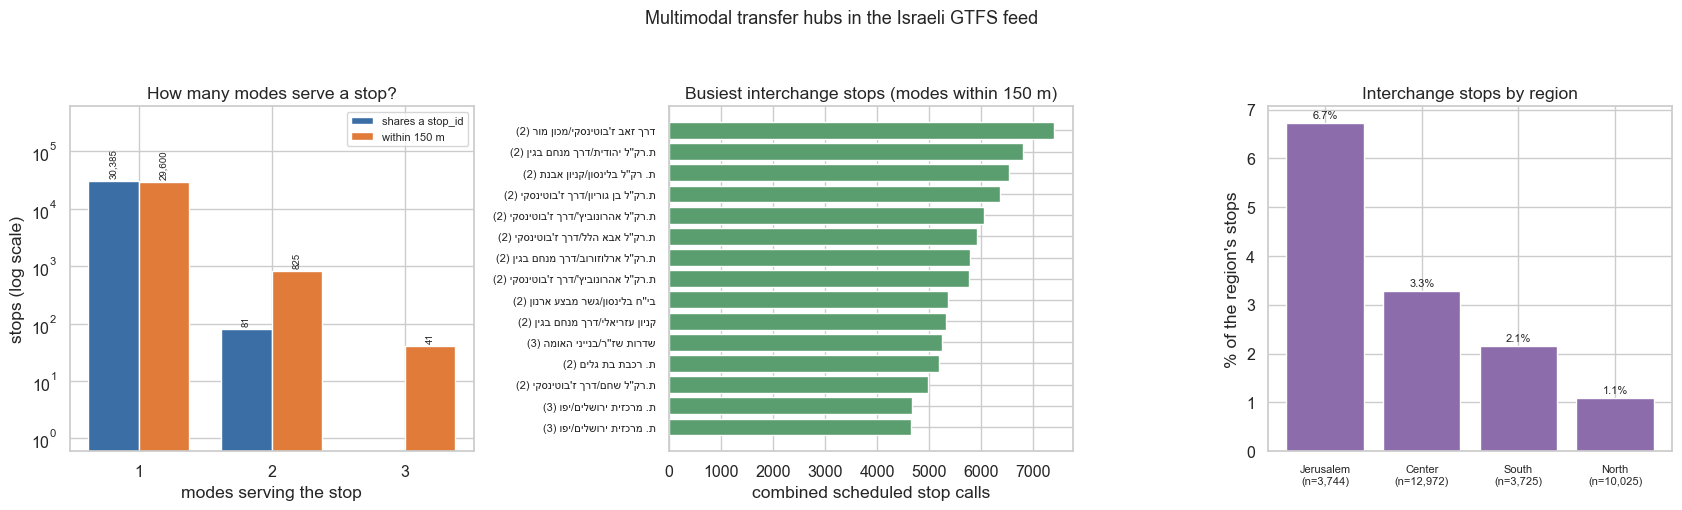

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs\figures\hub_inventory.png


In [19]:
# --- Figure 1: hub inventory ---------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

# Panel 1: distribution of modes per stop, both definitions
ax = axes[0]
strict_counts = hubs['n_modes'].value_counts().sort_index()
walk_counts = hubs['walk_n_modes'].value_counts().sort_index()
levels = sorted(set(strict_counts.index) | set(walk_counts.index))
x = np.arange(len(levels))
width = 0.38
bars1 = ax.bar(x - width / 2, [strict_counts.get(k, 0) for k in levels], width,
               label='shares a stop_id', color='#3b6ea5')
bars2 = ax.bar(x + width / 2, [walk_counts.get(k, 0) for k in levels], width,
               label=f'within {WALK_RADIUS_M} m', color='#e07b39')
for bars in (bars1, bars2):
    ax.bar_label(bars, labels=[f'{int(b.get_height()):,}' if b.get_height() else ''
                               for b in bars], fontsize=7, padding=2, rotation=90)
ax.set_yscale('log')
ax.set_ylim(0.6, max(strict_counts.max(), walk_counts.max()) * 20)
ax.set_xticks(x)
ax.set_xticklabels(levels)
ax.set_xlabel('modes serving the stop')
ax.set_ylabel('stops (log scale)')
ax.set_title('How many modes serve a stop?')
ax.legend(fontsize=8)

# Panel 2: top hubs by combined service volume
ax = axes[1]
top = (details[details['is_interchange']]
       .sort_values('total_stop_calls', ascending=False)
       .head(TOP_N_HUBS)
       .iloc[::-1])
ax.barh(range(len(top)), top['total_stop_calls'], color='#5a9e6f')
ax.set_yticks(range(len(top)))
ax.set_yticklabels([f'{name} ({n})' for name, n in
                    zip(top['stop_name'], top['walk_n_modes'])], fontsize=8)
ax.set_xlabel('combined scheduled stop calls')
ax.set_title(f'Busiest interchange stops (modes within {WALK_RADIUS_M} m)')

# Panel 3: interchange share by region
ax = axes[2]
by_region = (hubs.assign(region=hubs['region'].replace('', 'unknown'))
             .groupby('region')
             .agg(stops=('stop_id', 'size'),
                  interchange=('is_interchange', 'sum'),
                  multimodal=('is_multimodal', 'sum')))
by_region['interchange_share'] = by_region['interchange'] / by_region['stops'] * 100
by_region = by_region.sort_values('interchange_share', ascending=False)
bars = ax.bar(range(len(by_region)), by_region['interchange_share'], color='#8d6cab')
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in by_region['interchange_share']],
             fontsize=8, padding=2)
ax.set_xticks(range(len(by_region)))
ax.set_xticklabels([f'{idx}\n(n={int(row.stops):,})'
                    for idx, row in by_region.iterrows()], fontsize=8)
ax.set_ylabel("% of the region's stops")
ax.set_title('Interchange stops by region')

fig.suptitle('Multimodal transfer hubs in the Israeli GTFS feed', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(FIGURES / 'hub_inventory.png', dpi=FIG_DPI)
plt.show()
print('saved:', FIGURES / 'hub_inventory.png')

## 20. Figure 2 - the mode-interdependence graph

Two drawings of the same object under the two definitions. The nodes are modes, sized by the number of stations that mode serves (on a log scale, otherwise bus would be the only visible node); edges are drawn only where the weight is nonzero, at a width proportional to the square root of the weight, with the weight printed on the edge. A fixed circular layout keeps the two panels comparable and the figure reproducible - a spring layout would move the nodes between runs and between panels for no analytic gain.

The left panel is the strict graph: a single edge. The right panel is the walk-distance graph, and it's a connected star centered on bus. That shape is itself this notebook's robustness statement: **every other mode's transfer capability runs through the bus network**, and none of the small modes connects to the others except through it.

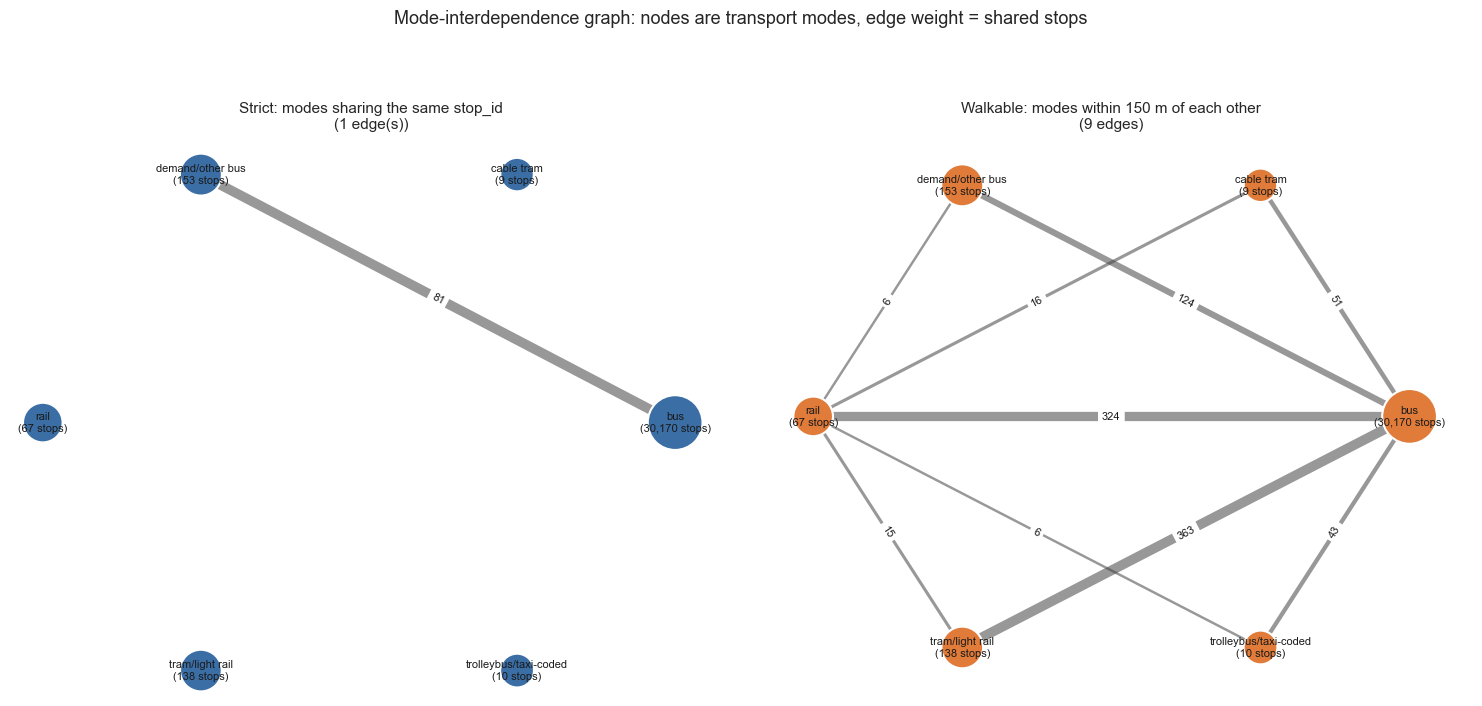

strict graph : 6 nodes, 1 edges, connected = False
walkable graph: 6 nodes, 9 edges, connected = True
saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs\figures\mode_interdependence_graph.png


In [20]:
# --- Figure 2: mode interdependence, both definitions --------------------
def draw_mode_graph(ax, pair_weights, node_sizes, title, colour):
    G = nx.Graph()
    for m in observed_modes:
        G.add_node(m, stops=node_sizes.get(m, 0))
    for (a, b), w in pair_weights.items():
        if w > 0:
            G.add_edge(a, b, weight=w)
    pos = nx.circular_layout(sorted(G.nodes()))
    sizes = [300 + 1400 * np.log10(1 + G.nodes[n]['stops']) / 5 for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=colour,
                           edgecolors='white', linewidths=1.5)
    if G.number_of_edges():
        weights = [G[u][v]['weight'] for u, v in G.edges()]
        widths = [1.0 + 6.0 * np.sqrt(w) / np.sqrt(max(weights)) for w in weights]
        nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.55,
                               edge_color='#444444')
        nx.draw_networkx_edge_labels(
            G, pos, ax=ax, font_size=8,
            edge_labels={(u, v): f'{G[u][v]["weight"]:,}' for u, v in G.edges()})
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8,
                            labels={n: f'{n}\n({G.nodes[n]["stops"]:,} stops)'
                                    for n in G.nodes()})
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    return G


strict_weights = {(r.mode_a, r.mode_b): int(r.shared_stops)
                  for r in interdependence.itertuples()}
walk_weights = {(r.mode_a, r.mode_b): int(r.interchange_stops)
                for r in interdependence_walk.itertuples()}
strict_sizes = {m: len(s) for m, s in mode_stop_sets.items()}

n_strict_edges = sum(1 for w in strict_weights.values() if w > 0)
n_walk_edges = sum(1 for w in walk_weights.values() if w > 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 7.2))
G_strict = draw_mode_graph(axes[0], strict_weights, strict_sizes,
                           'Strict: modes sharing the same stop_id\n'
                           f'({n_strict_edges} edge(s))',
                           '#3b6ea5')
G_walk = draw_mode_graph(axes[1], walk_weights, strict_sizes,
                         f'Walkable: modes within {WALK_RADIUS_M} m of each other\n'
                         f'({n_walk_edges} edges)',
                         '#e07b39')
fig.suptitle('Mode-interdependence graph: nodes are transport modes, '
             'edge weight = shared stops', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIGURES / 'mode_interdependence_graph.png', dpi=FIG_DPI)
plt.show()

print('strict graph : {} nodes, {} edges, connected = {}'.format(
    G_strict.number_of_nodes(), G_strict.number_of_edges(),
    nx.is_connected(G_strict) if G_strict.number_of_nodes() else False))
print('walkable graph: {} nodes, {} edges, connected = {}'.format(
    G_walk.number_of_nodes(), G_walk.number_of_edges(),
    nx.is_connected(G_walk) if G_walk.number_of_nodes() else False))
print('saved:', FIGURES / 'mode_interdependence_graph.png')

## 21. Figure 3 - where the hubs are

A geographic scatter with all stations in light gray as background, the two hub definitions laid over it, and the largest hubs labeled. The aspect ratio is corrected with `cos(latitude)` so the country doesn't stretch horizontally.

* **Left panel** - multimodal stations in the strict sense. They're scattered across the country with no transfer logic to them, which is exactly what you'd expect if the "multimodality" is a recording artifact of demand-responsive services sharing bus stops.
* **Right panel** - walk-distance interchange stops, colored by the number of reachable modes. These cluster hard toward the Tel Aviv, Jerusalem, and Haifa arteries and along the rail axis, and it looks like real interchange geography. The busiest `MAP_ANNOTATE` are labeled by name.

Comparing the two panels is the fastest way to understand why the notebook doesn't stop at the strict definition.

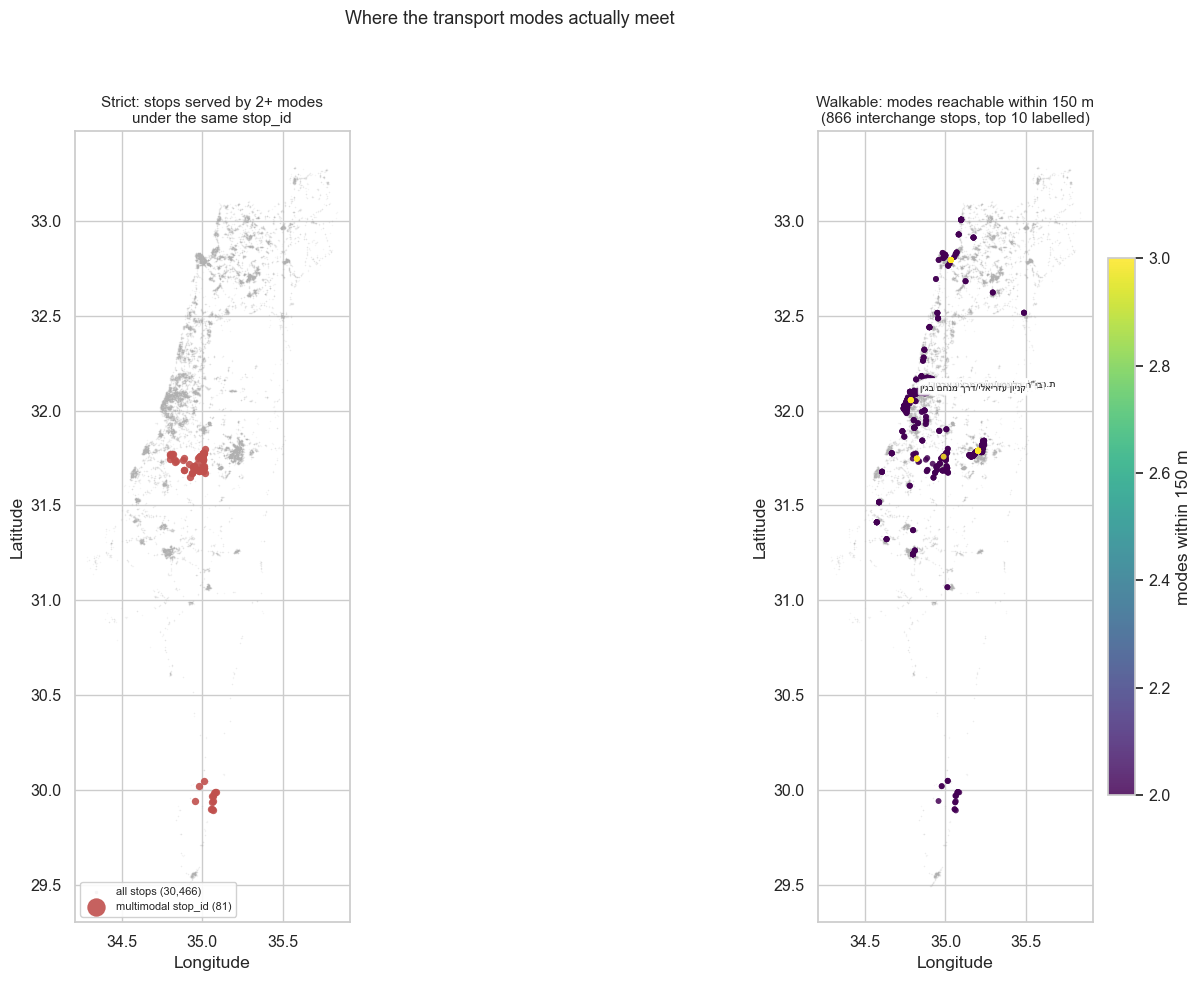

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs\figures\transfer_hub_map.png


In [21]:
# --- Figure 3: hub geography ---------------------------------------------
geo = hubs.dropna(subset=['lat', 'lon'])
aspect = 1 / np.cos(np.deg2rad(float(geo['lat'].mean())))

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Left: strict multimodal stops
ax = axes[0]
ax.scatter(geo['lon'], geo['lat'], s=1, alpha=0.12, linewidths=0, color='#b0b0b0',
           label=f'all stops ({len(geo):,})')
strict_geo = geo[geo['is_multimodal']]
ax.scatter(strict_geo['lon'], strict_geo['lat'], s=28, alpha=0.9, linewidths=0,
           color='#c0504d', label=f'multimodal stop_id ({len(strict_geo):,})')
ax.set_aspect(aspect)
ax.set_title('Strict: stops served by 2+ modes\nunder the same stop_id', fontsize=11)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left', fontsize=8, markerscale=2.5, framealpha=0.9)

# Right: walkable interchange stops, coloured by walkable mode count
ax = axes[1]
ax.scatter(geo['lon'], geo['lat'], s=1, alpha=0.12, linewidths=0, color='#b0b0b0')
inter_geo = geo[geo['is_interchange']].sort_values('walk_n_modes')
scatter = ax.scatter(inter_geo['lon'], inter_geo['lat'], s=18, alpha=0.85, linewidths=0,
                     c=inter_geo['walk_n_modes'], cmap='viridis')
cbar = fig.colorbar(scatter, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('modes within {} m'.format(WALK_RADIUS_M))

label_me = (details[details['is_interchange']]
            .dropna(subset=['lat', 'lon'])
            .sort_values('total_stop_calls', ascending=False)
            .head(MAP_ANNOTATE))
for _, row in label_me.iterrows():
    ax.annotate(row['stop_name'], (row['lon'], row['lat']),
                textcoords='offset points', xytext=(6, 4), fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.75))
ax.set_aspect(aspect)
ax.set_title(f'Walkable: modes reachable within {WALK_RADIUS_M} m\n'
             f'({len(inter_geo):,} interchange stops, top {MAP_ANNOTATE} labelled)',
             fontsize=11)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

fig.suptitle('Where the transport modes actually meet', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIGURES / 'transfer_hub_map.png', dpi=FIG_DPI)
plt.show()
print('saved:', FIGURES / 'transfer_hub_map.png')

## 22. Figure 4 - are multimodal stations more structurally important?

The tests from section 16, drawn.

* **Left** - betweenness by group, as box plots on a log axis with `log10(betweenness + eps)`. The offset is needed because a large share of stations have betweenness exactly zero and `log(0)` is undefined; the shift is applied identically to both groups so it can't change the order, and the test itself was run on the raw values, not the transformed ones. The boxes are notched, so non-overlapping notches roughly indicate a significant difference in medians.
* **Right** - articulation-point rate by group with **95% Wilson error bars**, and here the small size of the strict multimodal group becomes visible as a wide interval. The annotation on each pair gives the odds ratio and the Holm-corrected p-value, so the figure carries the same numbers as the table and can't drift from it.

The two panels together are the answer to the notebook's research question, and they don't answer it the same way for the two definitions.

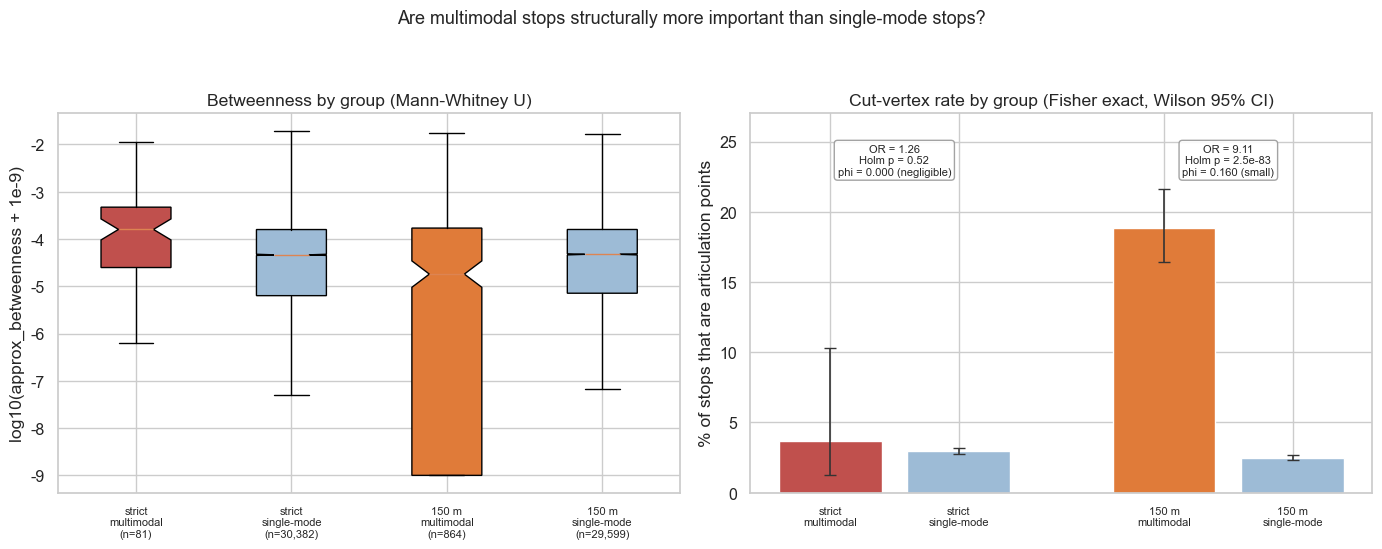

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs\figures\structural_importance.png


In [22]:
# --- Figure 4: structural importance, by definition ----------------------
EPS = 1e-9
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))

# Left: betweenness distributions
ax = axes[0]
box_data, box_labels = [], []
for flag, definition in DEFINITIONS:
    for is_group, tag in [(True, 'multimodal'), (False, 'single-mode')]:
        values = analysis.loc[analysis[flag] == is_group, BETWEENNESS].to_numpy(dtype=float)
        box_data.append(np.log10(values + EPS))
        short = 'strict' if flag == 'is_multimodal' else f'{WALK_RADIUS_M} m'
        box_labels.append(f'{short}\n{tag}\n(n={len(values):,})')
bp = ax.boxplot(box_data, showfliers=False, notch=True, patch_artist=True)
ax.set_xticks(range(1, len(box_labels) + 1))
ax.set_xticklabels(box_labels)
for patch, colour in zip(bp['boxes'], ['#c0504d', '#9dbbd6', '#e07b39', '#9dbbd6']):
    patch.set_facecolor(colour)
ax.set_ylabel('log10(approx_betweenness + 1e-9)')
ax.set_title('Betweenness by group (Mann-Whitney U)')
ax.tick_params(axis='x', labelsize=8)

# Right: articulation-point rates with Wilson intervals
ax = axes[1]
positions, heights, errors, labels, colours = [], [], [], [], []
for k, (flag, definition) in enumerate(DEFINITIONS):
    row = tests[(tests['definition'] == definition) &
                (tests['outcome'] == 'is_articulation_point')].iloc[0]
    for j, (rate, n_group, tag, colour) in enumerate([
            (row['rate_multimodal'], row['n_multimodal'], 'multimodal',
             '#c0504d' if k == 0 else '#e07b39'),
            (row['rate_single_mode'], row['n_single_mode'], 'single-mode', '#9dbbd6')]):
        successes = int(round(rate * n_group))
        lo, hi = wilson_interval(successes, int(n_group))
        positions.append(k * 2.6 + j)
        heights.append(rate * 100)
        errors.append([(rate - lo) * 100, (hi - rate) * 100])
        short = 'strict' if flag == 'is_multimodal' else f'{WALK_RADIUS_M} m'
        labels.append(f'{short}\n{tag}')
        colours.append(colour)
err = np.array(errors).T
ax.bar(positions, heights, color=colours, width=0.8,
       yerr=err, capsize=4, error_kw={'ecolor': '#333333', 'lw': 1.2})
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('% of stops that are articulation points')
ax.set_title('Cut-vertex rate by group (Fisher exact, Wilson 95% CI)')
top_y = max(h + e for h, e in zip(heights, err[1])) * 1.25
ax.set_ylim(0, top_y)
for k, (flag, definition) in enumerate(DEFINITIONS):
    row = tests[(tests['definition'] == definition) &
                (tests['outcome'] == 'is_articulation_point')].iloc[0]
    ax.text(k * 2.6 + 0.5, top_y * 0.92,
            f'OR = {row["odds_ratio"]:.2f}\nHolm p = {row["p_value_holm"]:.2g}\n'
            f'phi = {row["effect_size"]:.3f} ({row["effect_size_reading"]})',
            ha='center', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#999999', alpha=0.9))

fig.suptitle('Are multimodal stops structurally more important than single-mode stops?',
             fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIGURES / 'structural_importance.png', dpi=FIG_DPI)
plt.show()
print('saved:', FIGURES / 'structural_importance.png')

## 23. `multimodal_summary.json`

The third required output: every key number in one machine-readable file, so the report never has to re-derive a figure by hand from a CSV. It carries the mode inventory, both interdependence structures, the hub counts under both definitions, the full test results with effect sizes, the degree-adjusted odds ratios, the radius sensitivity check, and the top hubs by service volume. `default=float` handles numpy scalars; `ensure_ascii=False` keeps Hebrew station names readable inside the file itself.

In [23]:
# --- multimodal_summary.json ---------------------------------------------
top_records = (details.sort_values(['walk_n_modes', 'total_stop_calls'], ascending=False)
               .head(TOP_N_HUBS)[['stop_id', 'stop_name', 'region', 'n_modes',
                                  'modes_served', 'walk_n_modes', 'walk_modes_served',
                                  'total_stop_calls', 'is_articulation_point']]
               .to_dict(orient='records'))

summary = {
    'stage': '17_multimodal_transfer_hubs',
    'walk_radius_m': WALK_RADIUS_M,
    'stops_in_feed': int(len(hubs)),
    'stops_with_structural_metrics': int(len(analysis)),
    'stop_time_rows_read': int(stream_stats['rows_read']),
    'modes': {
        m: {'route_type': next((r['route_type'] for _, r in mode_meta.iterrows()
                                if r['mode_label'] == m), ''),
            'stops': int(len(mode_stop_sets.get(m, ()))),
            'stop_calls': int(sum(stop_calls.get(m, {}).values())),
            'trips_observed': int(stream_stats['trips_observed'].get(m, 0))}
        for m in observed_modes},
    'strict_definition': {
        'multimodal_stops': int(hubs['is_multimodal'].sum()),
        'share_of_stops': float(hubs['is_multimodal'].mean()),
        'max_modes_at_one_stop': int(hubs['n_modes'].max()),
        'mode_combinations': hubs.loc[hubs['is_multimodal'], 'modes_served']
                                 .value_counts().to_dict(),
        'mode_pairs_sharing_stops': int((interdependence['shared_stops'] > 0).sum()),
        'interdependence': interdependence.to_dict(orient='records'),
    },
    'walkable_definition': {
        'interchange_stops': int(hubs['is_interchange'].sum()),
        'share_of_stops': float(hubs['is_interchange'].mean()),
        'max_modes_within_radius': int(hubs['walk_n_modes'].max()),
        'radius_sensitivity': {f'{r}m': int(v) for r, v in sensitivity.items()},
        'mode_pairs_within_radius': int((interdependence_walk['interchange_stops'] > 0).sum()),
        'interdependence': interdependence_walk.to_dict(orient='records'),
    },
    'structural_tests': tests.to_dict(orient='records'),
    'degree_adjusted_odds_ratios': cmh_summary,
    'top_hubs': top_records,
    'caveats': [
        'GTFS stop_ids are per-mode records: a rail platform and the bus bay outside '
        'it are different stops, so the strict shared-stop_id definition understates '
        'real interchange.',
        'The walkable definition depends on an arbitrary radius; 100/150/250 m are '
        'reported in radius_sensitivity.',
        'Betweenness is stage 04 approx_betweenness (sampled sources), not exact.',
        'Articulation points and betweenness come from the merged all-mode graph, '
        'which is numerically dominated by bus.',
        'Effect sizes, not p-values, carry the conclusion: n ~ 30,000 makes almost '
        'any difference statistically significant.',
    ],
}
with open(STAGE / 'multimodal_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, ensure_ascii=False, indent=2, default=float)

print('saved:', STAGE / 'multimodal_summary.json')
print(json.dumps({k: summary[k] for k in ('stops_in_feed', 'walk_radius_m')},
                 ensure_ascii=False))
print('strict multimodal stops   :', summary['strict_definition']['multimodal_stops'])
print('walkable interchange stops:', summary['walkable_definition']['interchange_stops'])

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\17_multimodal_transfer_hubs\multimodal_summary.json
{"stops_in_feed": 30466, "walk_radius_m": 150}
strict multimodal stops   : 81
walkable interchange stops: 866


## 24. Why interchange stops matter for robustness

The mechanism is simple, and it's the reason this notebook exists.

**A single-mode station fails in one network. An interchange stop fails in several networks at once.** Remove an ordinary bus stop and the bus graph loses a node; no other mode is affected, and riders who didn't use that stop notice nothing. Remove a station where bus meets rail and two things happen at once: the bus network loses a node, *and* the rail network loses its only on-foot access at that point. The rail line still runs - its own edges are intact - but a rail station you can't reach by bus has, from the rider's point of view, partly failed. Cascading failure in coupled networks isn't a metaphor here; it's what "the feeder bus stop is closed" means for someone standing on the platform.

**The coupling is asymmetric, and the asymmetry shows up in Figure 2.** The walk-distance interdependence graph is a **star centered on bus**. Rail, light rail, cable car, and the shared-taxi lines each connect to bus, and effectively not to each other. So the bus network isn't just the largest layer, it's the *transfer substrate*: it's what every other mode connects through. Notebook 14 showed that bus is the only mode with real alternate routes; this notebook shows that it's also the only one connecting all the others. A disruption to bus service on some artery therefore hurts the accessibility of every other mode on that artery at the same time, whereas a rail failure leaves the bus network structurally intact.

**Interchange stops are where redundancy is unevenly distributed.** Notebook 14 found that the fixed-track modes are nearly path graphs: almost every intermediate station is a cut point of its own network. Those stations are also, by construction, the ones that appear in the walk-distance interchange set. So the stations where modes meet inherit the *worst* redundancy properties of the sparsest mode present, not the best properties of the densest one. The degree-band table in section 17 shows this directly: the excess cut-point rate among interchange stops is concentrated in the **low-degree** bands - stations with two or three neighbors that nonetheless anchor a transfer between modes. These are exactly the "quiet but critical" stations that a traffic-based priority list misses, the same pattern notebook 12 found for rail.

**But - and here the evidence has to be presented honestly - the effect sizes are small.** Under the strict definition there's essentially *no* difference in cut-point rate: the odds ratio is close to 1, Fisher's p-value is far from significant, phi is on the order of 0.001, and the degree-adjusted odds ratio is if anything below 1. The betweenness difference under that same definition is statistically significant, but the rank-biserial correlation is around 0.25 - a small effect, and one that shrinks further once degree is taken into account. The strict answer to "are multimodal stations more important?" is: **barely, and mostly because they're in busier places.**

Under the walk-distance definition, the association with cut-point status is much stronger - a cut-point rate several times the baseline, an odds ratio well above 1, and it survives stratification by degree with a CMH odds ratio far from 1. But even there phi is around 0.16, which by the usual convention is a *small* effect, and the direction of the betweenness comparison **flips**: walk-distance interchange stops have a *lower* median betweenness than ordinary stations. This isn't a contradiction and shouldn't be glossed over. It means these stations are cut points in the *sparse periphery* - rail stations at the edge of built-up areas, light-rail stations on a linear artery - not intermediaries in the dense metropolitan fabric where betweenness accumulates. They're critical in the sense that removing them disconnects something; they aren't critical in the sense that a lot of traffic flows through them.

**What all this implies for prioritization.** An operator ranking stations for hardening shouldn't use "serves more than one mode" as a criterion on its own - on this evidence it buys very little, and under the strict GTFS definition it buys almost nothing. What should be used is the *combination* found here: **a station that is a cut point, sits within walking distance of a second mode, and carries meaningful scheduled volume.** `tables/transfer_hub_details.csv` carries exactly those three columns for every station, so the combination can be selected directly. This group is small, and its members don't look impressive in a traffic-based ranking - which is the whole reason to run a structural analysis.

**Limitations that qualify everything above.**

* **The strict definition measures how GTFS is recorded, not transport.** This is the dominant limitation. It's why the notebook reports both definitions and refuses to pick one as "the answer".
* **The walk radius is a modeling choice.** 150 m is defensible; 100 m and 250 m give different group sizes (section 13 prints all three). The *direction* of each result is stable across the three radii, but the magnitudes aren't.
* **Walk distance is straight-line distance.** No barrier is modeled - a highway, a rail cut, or a river between two stations 120 m apart makes them, in practice, not-a-transfer-terminal.
* **Articulation points and betweenness come from the merged graph**, numerically dominated by bus. A "cut point" here is a cut point of the combined trip-adjacency network, not of any single mode.
* **The betweenness is approximate** (sampled sources, stage 04). Stage 04's own stability check bounds the sampling error; it's small relative to the between-group differences reported here, but not zero.
* **The effect sizes carry the conclusion, not the p-values.** With n ~ 30,000, a difference of no practical meaning routinely reaches p < 1e-50. So every test above is reported with an effect size and a plain-language reading of it, and the text says "small" where it's small.

## Conclusions

* **Modes in Israel almost never share a GTFS station.** Only a tiny fraction of stations serve more than one mode, none serve more than two, and the mixed pair is nearly always bus + demand-responsive bus - two codes for the same physical bus stop. **Bus and rail share zero `stop_id` values.** Any analysis that defines a "transfer hub" as a "shared station identifier" in this file is measuring a data-entry convention.
* **Moving to a walk-distance definition reveals the interchange geography.** Within 150 m, hundreds of stations reach a second mode, the mode pairs bus-rail, bus-light rail, bus-cable car, and bus-taxi all become non-empty, and the hubs cluster exactly where you'd expect: in the cores of Tel Aviv, Jerusalem, and Haifa and along the rail axis.
* **The interdependence graph is a star centered on bus.** Every secondary mode connects to bus and effectively not beyond it. Bus isn't just the largest layer of the Israeli network, it's the substrate through which every other mode is reachable - which makes a bus disruption the only kind of disruption that hits all modes at once.
* **The structural-importance claim is only half-supported, and the honest summary is "small".** Multimodal stations in the strict sense are *not* more likely to be cut points (odds ratio close to 1, Fisher p-value far from significant, phi ~ 0.001, degree-adjusted odds ratio below 1). Their betweenness is significantly higher by a rank test, but with a rank-biserial correlation around 0.25 - a small effect, largely explained by these stations sitting in busier places.
* **Walk-distance interchange stops *are* much more likely to be cut points**, by a factor of several, and the association survives stratification by degree. But phi is around 0.16 - still a small effect on the usual scale - and their median betweenness is *lower* than that of ordinary stations. They're cut points in the sparse periphery, not intermediaries in the dense core. Both facts are reported because either one alone would mislead.
* **The operational conclusion is a combination, not a single flag.** "Serves two modes" is a weak criterion for hardening. "It's a cut point, it has a second mode within walking distance, and it carries real scheduled volume" is a strong one, and it selects a small, specific, non-obvious set of stations - which `tables/transfer_hub_details.csv` is built to let the reader extract with a single filter.
* **Everything here is the supply side.** GTFS has no demand data, so "service volume" is scheduled calls and "important" means important in the timetable graph. A station with a low call count that happens to be an entire town's only transfer terminal is underweighted by every metric in this notebook, and no amount of statistics fixes that - only demand data would.